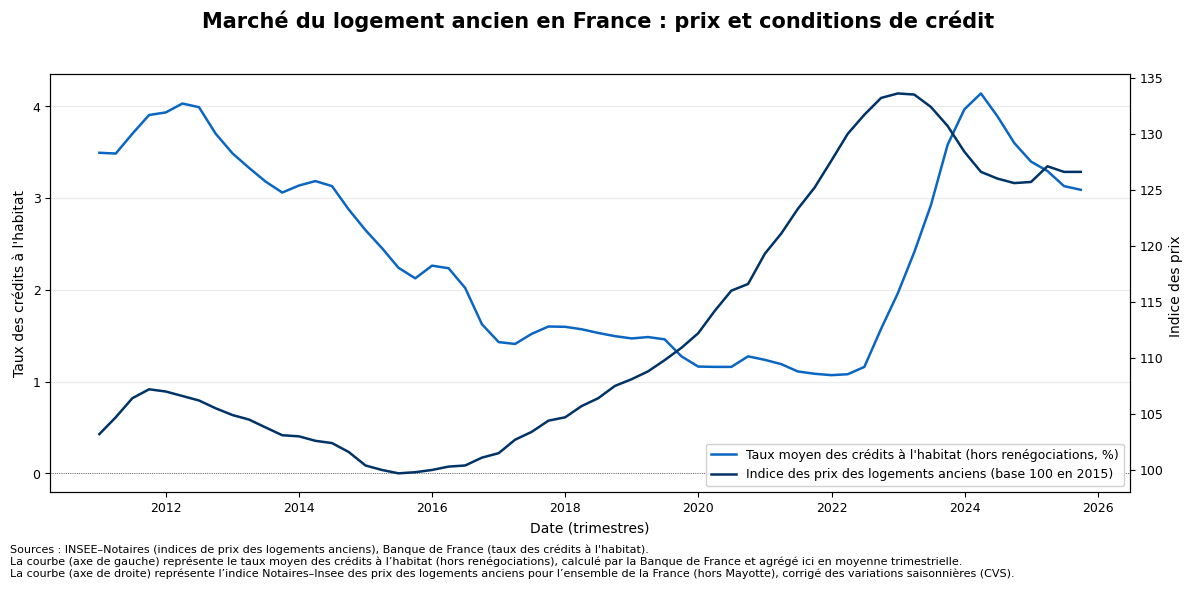

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------------------------------------------------
# 0. File paths + series identifiers
# --------------------------------------------------------------------
XLS_PATH   = r"C:\Users\GODLEWSKI\Downloads\sl_IPLA.xlsx"
PATH_TAUX  = r"C:\Users\GODLEWSKI\Downloads\chart (1).csv"

# Example: France entière – ensemble – CVS (adapt if needed)
IDPROD_INSEE = "IPLA-FE-E-CVS-2015"   # check the exact code in Indices_v4

# --------------------------------------------------------------------
# 1. INSEE helper: extract quarterly index by IDPROD
# --------------------------------------------------------------------
def extract_quarter_series_by_idprod(df, idprod, idbank=None):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    mask = df["IDPROD"] == idprod
    if idbank is not None:
        mask &= df["IDBANK"].astype(str).str.strip() == str(idbank)

    row = df.loc[mask]
    if row.empty:
        raise KeyError(f"Series {idprod} (idbank={idbank}) not found in this sheet")
    row = row.iloc[0]

    qcols = []
    q_list = []
    y_list = []
    for c in df.columns:
        m = re.search(r"^T([1-4])\s+(\d{4})", c)
        if m:
            qcols.append(c)
            q_list.append(m.group(1))
            y_list.append(m.group(2))

    values = []
    dates = []
    for c, q, y in zip(qcols, q_list, y_list):
        v = row[c]
        if pd.isna(v):
            continue
        year = int(y)
        month = {"1": 3, "2": 6, "3": 9, "4": 12}[q]
        date = pd.Timestamp(year, month, 1) + pd.offsets.MonthEnd(0)
        dates.append(date)
        values.append(float(v))

    s = pd.Series(values, index=dates).sort_index()
    return s

# --------------------------------------------------------------------
# 2. BdF helpers: French months + numeric conversion
# --------------------------------------------------------------------
MONTH_MAP = {
    "janv.": 1,
    "févr.": 2,
    "mars": 3,
    "avr.": 4,
    "mai": 5,
    "juin": 6,
    "juil.": 7,
    "août": 8,
    "sept.": 9,
    "oct.": 10,
    "nov.": 11,
    "déc.": 12,
}

def parse_french_month(cat: str) -> pd.Timestamp:
    cat = str(cat).strip()
    parts = cat.split()
    if len(parts) != 2:
        return pd.NaT
    m_str, y_str = parts
    month = MONTH_MAP[m_str]
    year = int(y_str)
    return pd.Timestamp(year, month, 1) + pd.offsets.MonthEnd(0)

def to_float_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace("\u00a0", "")
         .str.replace(",", ".")
         .replace("nan", pd.NA)
         .astype("string")
         .astype("Float64")
    )

# --------------------------------------------------------------------
# 3. INSEE index (quarterly)
# --------------------------------------------------------------------
xls = pd.ExcelFile(XLS_PATH)
indices_df = pd.read_excel(xls, sheet_name="Indices_v4")

idx_insee = extract_quarter_series_by_idprod(indices_df, IDPROD_INSEE)
idx_insee.name = "prix_logement"

# Rebase to 100 at start (optional)
base = idx_insee.iloc[0]
idx_rebased = idx_insee / base * 100
idx_rebased.name = "prix_logement_100"

# --------------------------------------------------------------------
# 4. BdF mortgage rate (monthly -> quarterly average)
# --------------------------------------------------------------------
df_taux = pd.read_csv(PATH_TAUX, sep=";")
df_taux["date"] = df_taux["Category"].apply(parse_french_month)
df_taux["taux_hors_renego"] = to_float_series(
    df_taux["Taux hors renégociations"]
)

taux_m = (
    df_taux[["date", "taux_hors_renego"]]
    .dropna()
    .set_index("date")
    .sort_index()
)

# Use 'QE' instead of deprecated 'Q'
taux_q = taux_m["taux_hors_renego"].resample("QE").mean()
taux_q.name = "taux_moyen"

# --------------------------------------------------------------------
# 5. Merge at quarterly frequency
# --------------------------------------------------------------------
df_q = pd.concat([idx_insee, taux_q], axis=1).dropna().sort_index()

# --------------------------------------------------------------------
# 6. Plot: left axis = mortgage rate, right axis = price index
# --------------------------------------------------------------------
fig, ax_left = plt.subplots(figsize=(12, 6))

COLOR_RATE = "#0A66C2"
COLOR_INDEX = "#003366"

# Left axis: mortgage rate
ax_left.plot(
    df_q.index,
    df_q["taux_moyen"],
    label="Taux moyen des crédits à l'habitat (hors renégociations, %)",
    color=COLOR_RATE,
    linewidth=1.8,
)
ax_left.set_ylabel("Taux des crédits à l'habitat")
ax_left.set_xlabel("Date (trimestres)")
ax_left.axhline(0, color="#444", linewidth=0.6, linestyle=":")
ax_left.grid(axis="y", alpha=0.25)
ax_left.set_axisbelow(True)

# Right axis: housing price index (rebased)
ax_right = ax_left.twinx()
ax_right.plot(
    df_q.index,
    df_q["prix_logement"],
    label="Indice des prix des logements anciens (base 100 en 2015)",
    color=COLOR_INDEX,
    linewidth=1.8,
)
ax_right.set_ylabel("Indice des prix ")

# Legend
lines_l, labels_l = ax_left.get_legend_handles_labels()
lines_r, labels_r = ax_right.get_legend_handles_labels()
ax_left.legend(
    lines_l + lines_r,
    labels_l + labels_r,
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=9,
)

fig.suptitle(
    "Marché du logement ancien en France : prix et conditions de crédit",
    fontsize=15,
    fontweight="bold",
    y=0.95,
)

fig.text(
    0.01,
    0.001,
    "Sources : INSEE–Notaires (indices de prix des logements anciens), "
    "Banque de France (taux des crédits à l'habitat).\n"
    "La courbe (axe de gauche) représente le taux moyen des crédits à l’habitat (hors renégociations), calculé par la Banque de France et agrégé ici en moyenne trimestrielle. \n"
    "La courbe (axe de droite) représente l’indice Notaires–Insee des prix des logements anciens pour l’ensemble de la France (hors Mayotte), corrigé des variations saisonnières (CVS).",
    fontsize=8,
    ha="left",
    va="bottom",
)

ax_left.tick_params(axis="both", labelsize=9)
ax_right.tick_params(axis="y", labelsize=9)
ax_right.grid(False)

fig.tight_layout(rect=(0, 0.05, 1, 0.93))
plt.show()
